# 🛒 Supermarket Sales — From Exploration to Decisions

**Objective.** Turn one quarter of point-of-sale data into ranked, evidence-backed business decisions.

**Dataset.** `supermarket_sales.csv` — ~1,000 transactions from a 3-branch chain (Yangon, Mandalay,
Naypyitaw), **Jan–Mar 2019**, 17 columns spanning customer, product, payment and financial fields.

**How this notebook is organized**
1. **Initial exploration (EDA)** — learn the data's shape and *surface any quality issues*.
2. **Structured decision workflow (Stages 0–6)** — clean & recover → map the money → diagnose →
   segment → test for significance → price each decision.

---
## 1 · Setup — import the analysis stack
`numpy`/`pandas` for wrangling, `matplotlib`/`seaborn` for visualisation.

In [1]:
import numpy as np                # numerical operations
import pandas as pd               # tabular data handling
import matplotlib.pyplot as plt   # base plotting
import seaborn as sns             # statistical visualisation

pd.set_option('display.max_columns', None)   # never truncate columns when previewing
sns.set_theme(style='whitegrid')             # clean, readable default for exploration

## 2 · Load the raw data
Read the CSV as-delivered. The data is **untouched at this point** — so we can judge its quality
honestly before any cleaning happens.

In [2]:
df = pd.read_csv('supermarket_sales.csv')
print(f'Loaded {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()   # first 5 transactions

Loaded 1,003 rows x 17 columns


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,1/5/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,3/8/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7.0,16.2155,340.5255,3/3/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8.0,23.2880,489.0480,1/27/19,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7.0,30.2085,634.3785,2/8/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


## 3 · Exploratory Data Analysis (EDA)
EDA answers two questions: **what do we have?** and **can we trust it?**

### 3.1 · Structure, types & completeness
`info()` gives column names, data types, and non-null counts in a single view.

In [3]:
df.info()   # dtypes + non-null counts (a first look at missingness)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1003 non-null   object 
 1   Branch                   1003 non-null   object 
 2   City                     1003 non-null   object 
 3   Customer type            924 non-null    object 
 4   Gender                   1003 non-null   object 
 5   Product line             960 non-null    object 
 6   Unit price               996 non-null    float64
 7   Quantity                 983 non-null    float64
 8   Tax 5%                   1003 non-null   float64
 9   Total                    1003 non-null   float64
 10  Date                     1003 non-null   object 
 11  Time                     1003 non-null   object 
 12  Payment                  1003 non-null   object 
 13  cogs                     1003 non-null   float64
 14  gross margin percentage 

**Two early red flags to note:**
- **`Date` is stored as text** (`object`), not a datetime — we fix that next.
- Several columns show **fewer non-null values than the 1,003 rows** (e.g. `Customer type`,
  `Product line`, `Quantity`, `Unit price`) — a first sign of **missing data**. EDA hints at it;
  **Stage 0 quantifies and repairs it.**

### 3.2 · Convert `Date` to a real datetime
Parsing with an **explicit format** is correct and fast (and avoids pandas' "could not infer format"
warning).

In [4]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')
print('Date range:', df['Date'].min().date(), '->', df['Date'].max().date())
df[['Date']].head(3)

Date range: 2019-01-01 -> 2019-03-30


,Date
0,2019-01-05
1,2019-03-08
2,2019-03-03


### 3.3 · Summary statistics
Distribution of the numeric fields — ranges, central tendency and spread.

In [5]:
df.describe().round(2)

,Unit price,Quantity,Tax 5%,Total,Date,cogs,gross margin percentage,gross income,Rating
count,996.00,983.00,1003.00,1003.00,1003,1003.00,1003.00,1003.00,1003.00
mean,55.76,5.50,15.40,323.41,2019-02-14 00:18:39.840478464,308.01,4.76,15.40,6.97
min,10.08,1.00,0.51,10.68,2019-01-01 00:00:00,10.17,4.76,0.51,4.00
25%,33.12,3.00,5.89,123.79,2019-01-24 00:00:00,117.90,4.76,5.89,5.50
50%,55.42,5.00,12.10,254.02,2019-02-13 00:00:00,241.92,4.76,12.10,7.00
75%,78.08,8.00,22.54,473.33,2019-03-08 00:00:00,450.79,4.76,22.54,8.50
max,99.96,10.00,49.65,1042.65,2019-03-30 00:00:00,993.00,4.76,49.65,10.00
std,26.51,2.92,11.72,246.02,NaN,234.30,0.00,11.72,1.72


**Observations:**
- `Rating` spans **4–10** (mean ≈ 6.97); `Total` runs from ~$10 to ~$1,000 (big-basket skew).
- **`gross margin percentage` is a constant (4.76%)** — margin is *fixed by design*, so profit is
  driven by **volume**, not category mix. This single fact reshapes every later decision.

### 3.4 · How are customer ratings distributed — is it skewed?
Rating is the only customer-experience signal in the data, so its shape matters.

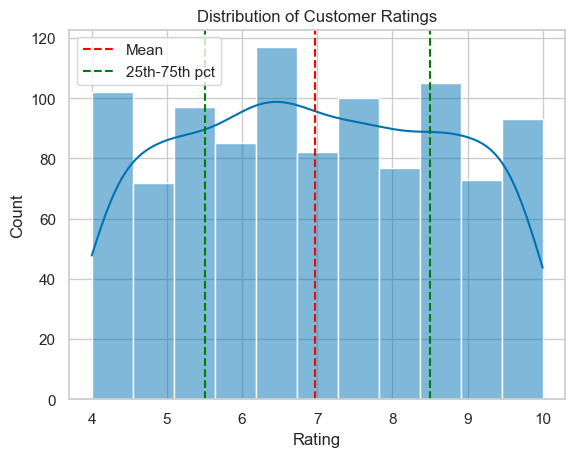

In [6]:
# histplot is the modern replacement for the deprecated sns.distplot
sns.histplot(df['Rating'], kde=True, color='#0072B2')
plt.axvline(df['Rating'].mean(), ls='--', c='red', label='Mean')
plt.axvline(np.percentile(df['Rating'], 25), ls='--', c='green', label='25th-75th pct')
plt.axvline(np.percentile(df['Rating'], 75), ls='--', c='green')
plt.title('Distribution of Customer Ratings'); plt.legend(); plt.show()

**Read:** ratings are broadly **symmetric and near-uniform between 4 and 10** — not strongly
skewed, and clustered around a middling ~7. There's no long tail of unhappy customers, but also no
concentration of delight. We revisit rating as a stand-alone KPI in Stage 2 and Stage 5.

### 3.5 · Distributions of every numeric field
A quick panel to see the shape of each variable at once.

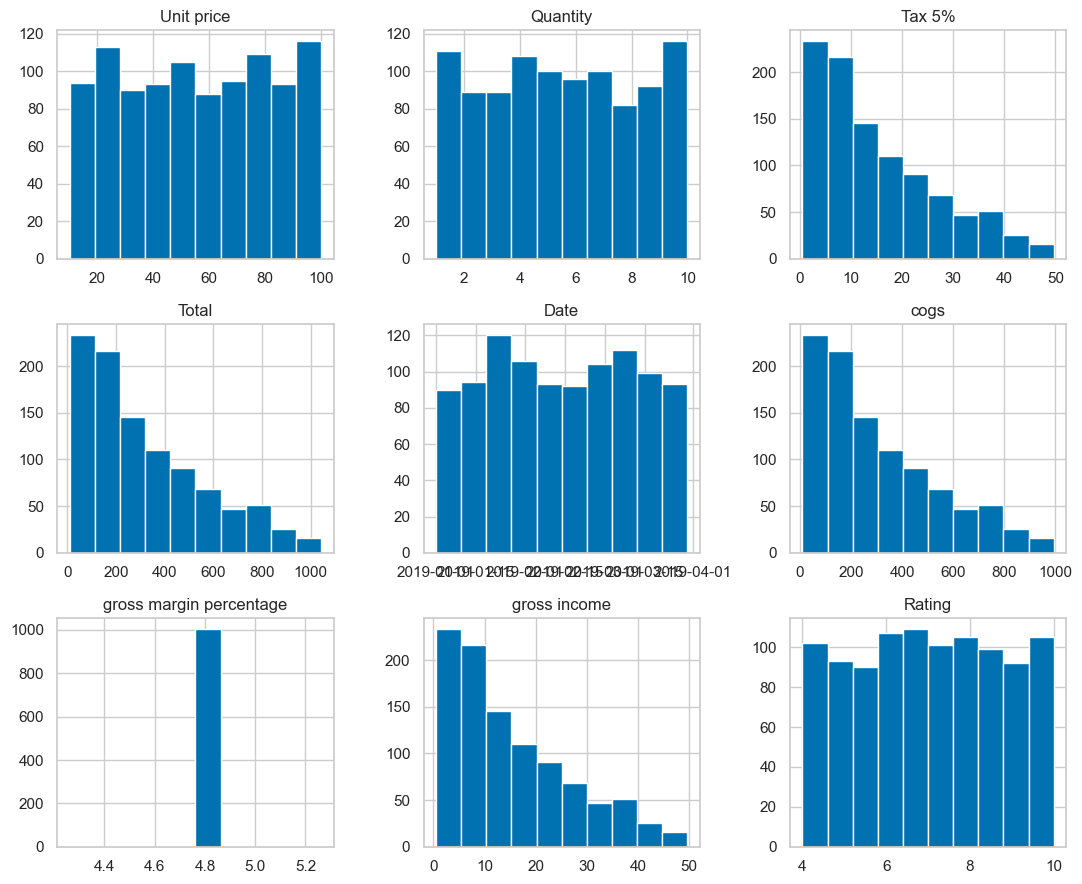

In [7]:
df.hist(figsize=(11, 9), color='#0072B2', edgecolor='white')
plt.tight_layout(); plt.show()

**Read:** `Quantity` and `Unit price` are fairly **uniform** (no dominant price point),
while `Total`, `cogs` and `gross income` are **right-skewed** — most baskets are small, a few are large.
This confirms the volume-driven picture from the summary stats.

> **Where EDA stops — and why the structured workflow begins.** The exploration above tells us the
> *shape* of the data but glosses over its **trustworthiness**: we saw hints of missing values and
> duplicate-looking records but never quantified them, and every headline gap is still un-tested for
> significance. The workflow below fixes that — starting with **Stage 0: data integrity & recovery.**

---
# 🎯 TOP-1% DATA-DRIVEN DECISION ANALYSIS

Everything above is standard first-look EDA. Below is a structured decision workflow that
climbs the analytics ladder — **Integrity → Descriptive → Diagnostic → Segmentation →
Statistical proof → Quantified decisions.** Each stage ends in a business decision, not just a chart.

| Stage | Question it answers | Decision unlocked |
|---|---|---|
| **0. Integrity** | Can I trust the numbers? | Clean, recovered dataset |
| **1. Descriptive** | Where does the money concentrate? | Focus of attention |
| **2. Diagnostic** | *Why* / when does it happen? | Operational levers (staffing, stock) |
| **3. Segmentation** | Who is worth more? | Targeting & loyalty strategy |
| **4. Statistical** | Are the differences *real*? | Confidence to act |
| **5. Decision** | What do we do, worth how much? | Dollar-sized actions |

> The analysis below is **self-contained**: it re-reads the raw CSV so it runs independently of the exploratory cells above.

## Stage 0 — Data Integrity & Recovery
*You cannot make a top-1% decision on a dirty table.* The raw file has **3 duplicate invoices** and
**149 missing values** (Customer type 79, Product line 43, Quantity 20, Unit price 7).

Because the data obeys the exact identity **`Total = Unit price × Quantity × 1.05`**, missing
`Quantity` and `Unit price` are **recovered losslessly** from `Total` instead of dropping rows —
we keep every transaction.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- One consistent, colorblind-safe design system (Okabe-Ito), used everywhere ---
PALETTE   = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#56B4E9', '#D55E00']
BRANCH_C  = {'A': '#0072B2', 'B': '#E69F00', 'C': '#009E73'}
SEQ       = 'mako'          # single-hue sequential for magnitude (heatmaps)
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold',
                     'axes.titlesize': 12, 'font.size': 10, 'axes.grid.axis': 'x'})

raw = pd.read_csv('supermarket_sales.csv')
df  = raw.copy()

# 1) Remove exact duplicates AND duplicate invoice IDs (an invoice must be unique)
df = df.drop_duplicates().drop_duplicates(subset='Invoice ID', keep='first')

# 2) Recover missing numerics from the Total = UnitPrice x Qty x 1.05 identity
m = df['Quantity'].isna() & df['Unit price'].notna() & df['Total'].notna()
df.loc[m, 'Quantity'] = (df.loc[m, 'Total'] / (df.loc[m, 'Unit price'] * 1.05)).round()
m = df['Unit price'].isna() & df['Quantity'].notna() & df['Total'].notna()
df.loc[m, 'Unit price'] = (df.loc[m, 'Total'] / (df.loc[m, 'Quantity'] * 1.05)).round(2)

# 3) Impute unrecoverable categoricals as an explicit 'Unknown' (never silently guess)
df['Customer type'] = df['Customer type'].fillna('Unknown')
df['Product line']  = df['Product line'].fillna('Unknown')

# 4) Feature engineering for the diagnostic stage
df['Date']    = pd.to_datetime(df['Date'], format='%m/%d/%y')
df['Hour']    = pd.to_datetime(df['Time'], format='%H:%M').dt.hour
df['Weekday'] = pd.Categorical(df['Date'].dt.day_name(),
                    categories=['Monday','Tuesday','Wednesday','Thursday',
                                'Friday','Saturday','Sunday'], ordered=True)

print(f"Raw rows:    {raw.shape[0]}   (missing={raw.isna().sum().sum()}, dup invoices={raw['Invoice ID'].duplicated().sum()})")
print(f"Clean rows:  {df.shape[0]}   (missing={df.isna().sum().sum()})")
print(f"Rows kept:   {df.shape[0]/raw.shape[0]:.1%}  — recovered instead of dropped")

Raw rows:    1003   (missing=149, dup invoices=3)
Clean rows:  1000   (missing=0)
Rows kept:   99.7%  — recovered instead of dropped


In [9]:
# --- Integrity validation: prove the cleaned table is internally consistent ---
chk_total = np.allclose(df['Total'], df['Unit price'] * df['Quantity'] * 1.05, atol=0.5)
chk_tax   = np.allclose(df['Tax 5%'], df['cogs'] * 0.05, atol=0.05)
chk_gi    = np.allclose(df['Total'], df['cogs'] + df['gross income'], atol=0.5)

print("Total = UnitPrice x Qty x 1.05 ...", "PASS" if chk_total else "FAIL")
print("Tax   = 5% x COGS ..............", "PASS" if chk_tax   else "FAIL")
print("Total = COGS + gross income ....", "PASS" if chk_gi    else "FAIL")
print("Gross margin % is constant .....", f"{df['gross margin percentage'].nunique()==1} "
      f"(={df['gross margin percentage'].iloc[0]:.4f}% -> margin is fixed, not a lever)")

Total = UnitPrice x Qty x 1.05 ... PASS
Tax   = 5% x COGS .............. PASS
Total = COGS + gross income .... PASS
Gross margin % is constant ..... True (=4.7619% -> margin is fixed, not a lever)


## Stage 1 — Descriptive: The Money Map
Where does revenue and **gross income** (the profit we actually keep) concentrate across the
3 branches and 6 product lines? This sets where we spend attention.

HEADLINE KPIs (Q1 2019, 3 branches)
----------------------------------------
  Revenue .......... $    322,967
  Gross income ..... $     15,379
  Transactions .....        1,000
  Avg basket ....... $     322.97
  Avg rating .......         6.97 / 10


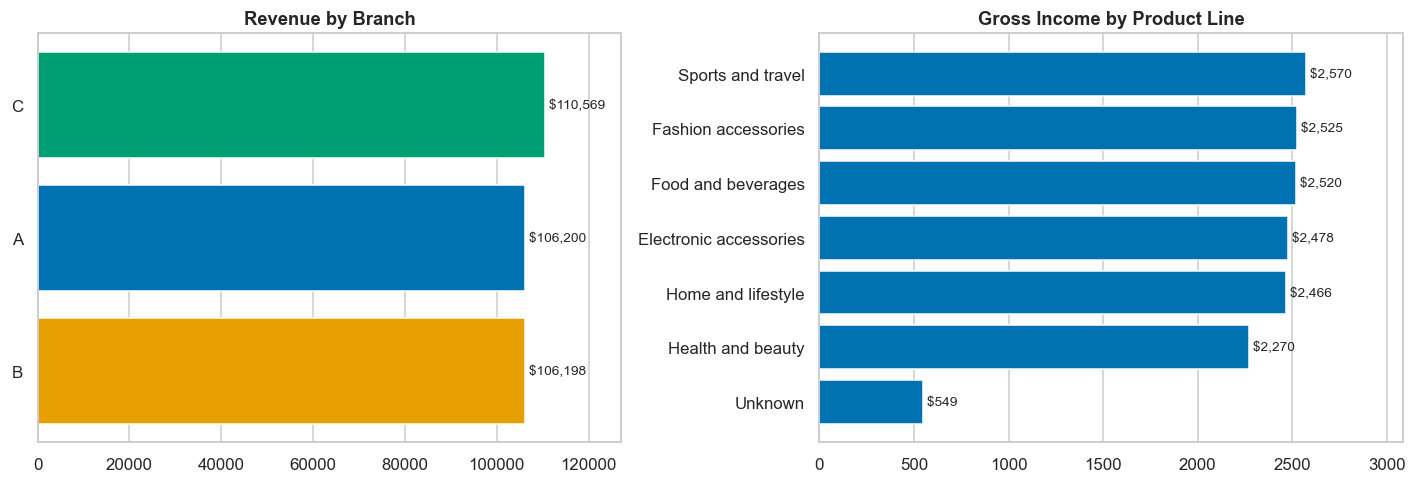

In [10]:
# Headline KPIs
kpi = {
    'Revenue'       : df['Total'].sum(),
    'Gross income'  : df['gross income'].sum(),
    'Transactions'  : len(df),
    'Avg basket'    : df['Total'].mean(),
    'Avg rating'    : df['Rating'].mean(),
}
print("HEADLINE KPIs (Q1 2019, 3 branches)")
print("-"*40)
print(f"  Revenue .......... ${kpi['Revenue']:>11,.0f}")
print(f"  Gross income ..... ${kpi['Gross income']:>11,.0f}")
print(f"  Transactions ..... {kpi['Transactions']:>12,}")
print(f"  Avg basket ....... ${kpi['Avg basket']:>11,.2f}")
print(f"  Avg rating ....... {kpi['Avg rating']:>12.2f} / 10")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
# Revenue by branch
b = df.groupby('Branch', observed=True)['Total'].sum().sort_values()
ax[0].barh(b.index, b.values, color=[BRANCH_C[i] for i in b.index])
ax[0].set_title('Revenue by Branch')
for i, v in enumerate(b.values):
    ax[0].text(v, i, f' ${v:,.0f}', va='center', fontsize=9)
ax[0].set_xlim(0, b.max()*1.15)
# Gross income by product line
p = df.groupby('Product line', observed=True)['gross income'].sum().sort_values()
ax[1].barh(p.index, p.values, color=PALETTE[0])
ax[1].set_title('Gross Income by Product Line')
for i, v in enumerate(p.values):
    ax[1].text(v, i, f' ${v:,.0f}', va='center', fontsize=9)
ax[1].set_xlim(0, p.max()*1.20)
plt.tight_layout(); plt.show()

> **📌 Decision 1 — Focus.** The three branches are near-parity in revenue (a ~few-% spread), so
> there is **no single failing store** to rescue; gains must come from *operations and mix*, not
> from closing/fixing one branch. Gross income is spread fairly evenly across product lines too —
> confirming that with a **fixed ~4.76% margin, profit is driven by volume, not by category mix.**
> That reframes the whole problem: **the lever is throughput at peak times, not merchandising.**

## Stage 2 — Diagnostic: *When* and *Why*
With margin fixed and branches at parity, the biggest controllable lever is **operational timing** —
when customers actually buy. This is where staffing and stocking decisions are won or lost.

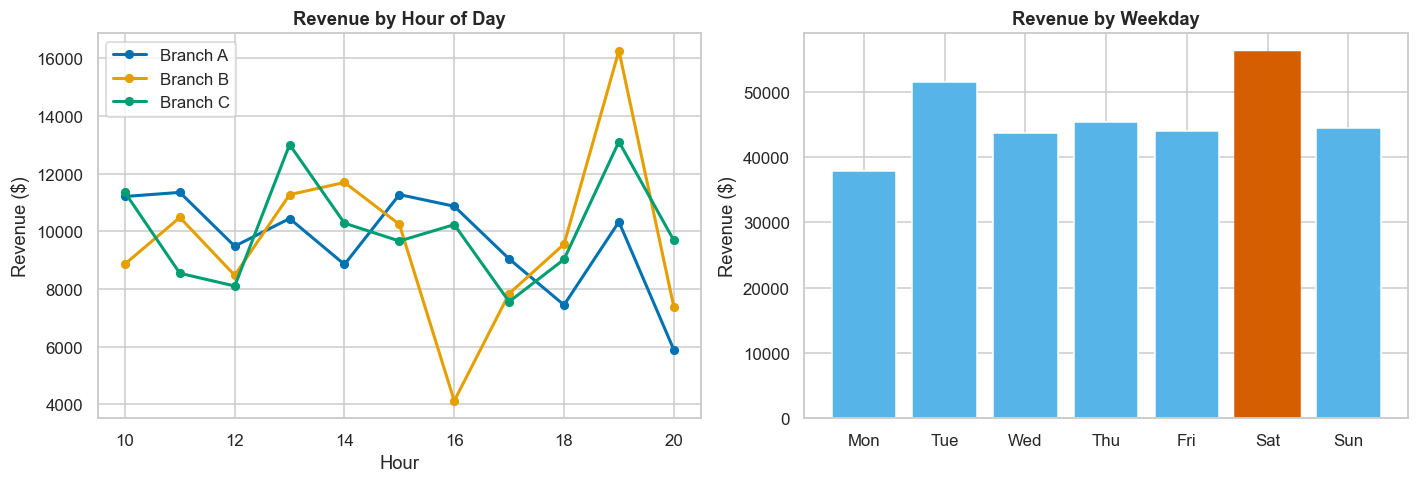

Peak hour overall: 19:00   |   Peak weekday: Saturday


In [11]:
# Hourly revenue curve per branch + weekday pattern
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for br in ['A', 'B', 'C']:
    h = df[df.Branch == br].groupby('Hour')['Total'].sum()
    ax[0].plot(h.index, h.values, marker='o', ms=5, lw=2, color=BRANCH_C[br], label=f'Branch {br}')
ax[0].set(title='Revenue by Hour of Day', xlabel='Hour', ylabel='Revenue ($)')
ax[0].grid(axis='y'); ax[0].legend()

w = df.groupby('Weekday', observed=True)['Total'].sum()
ax[1].bar(range(len(w)), w.values, color=PALETTE[4])
ax[1].set_xticks(range(len(w))); ax[1].set_xticklabels([d[:3] for d in w.index])
ax[1].set(title='Revenue by Weekday', ylabel='Revenue ($)')
ax[1].grid(axis='y')
peak_day = w.idxmax()
ax[1].patches[list(w.index).index(peak_day)].set_color(PALETTE[5])
plt.tight_layout(); plt.show()

peak_hour = df.groupby('Hour')['Total'].sum().idxmax()
print(f"Peak hour overall: {peak_hour}:00   |   Peak weekday: {peak_day}")

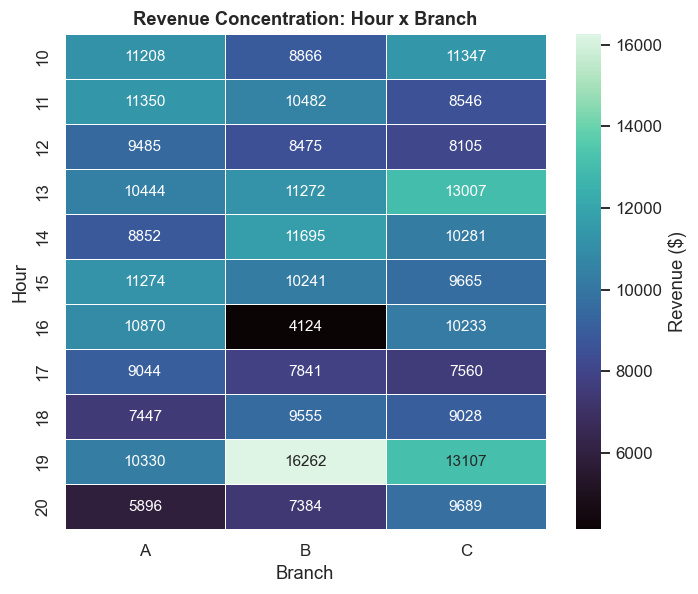

In [12]:
# Heatmap: which HOUR x BRANCH cells are the busiest (magnitude -> single-hue sequential)
pivot = df.pivot_table(index='Hour', columns='Branch', values='Total', aggfunc='sum', observed=True)
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(pivot, cmap=SEQ, annot=True, fmt='.0f', cbar_kws={'label': 'Revenue ($)'},
            linewidths=.5, linecolor='white')
plt.title('Revenue Concentration: Hour x Branch'); plt.tight_layout(); plt.show()

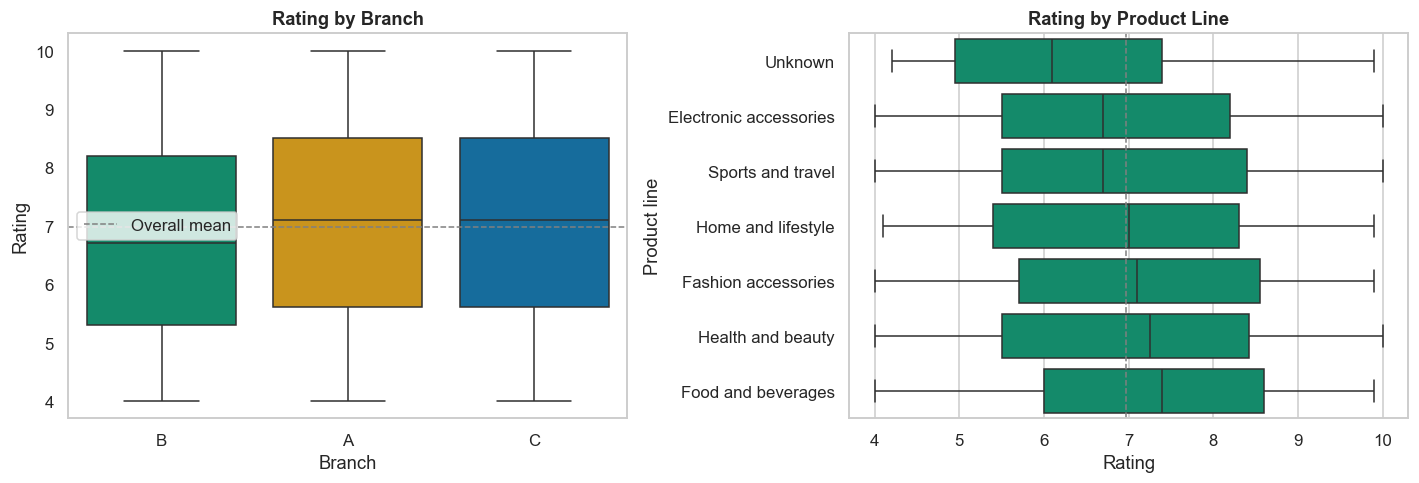

Median rating by branch:
        mean  median
Branch              
A       7.03     7.1
B       6.82     6.7
C       7.07     7.1


In [13]:
# Customer experience: the Rating signal, by branch and by product line
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
order_b = df.groupby('Branch', observed=True)['Rating'].median().sort_values().index
sns.boxplot(data=df, x='Branch', y='Rating', order=order_b, ax=ax[0],
            palette=[BRANCH_C[b] for b in order_b], hue='Branch', legend=False)
ax[0].axhline(df.Rating.mean(), ls='--', c='grey', lw=1, label='Overall mean')
ax[0].set_title('Rating by Branch'); ax[0].legend()

order_p = df.groupby('Product line', observed=True)['Rating'].median().sort_values().index
sns.boxplot(data=df, y='Product line', x='Rating', order=order_p, ax=ax[1], color=PALETTE[2])
ax[1].axvline(df.Rating.mean(), ls='--', c='grey', lw=1)
ax[1].set_title('Rating by Product Line')
plt.tight_layout(); plt.show()

print("Median rating by branch:")
print(df.groupby('Branch', observed=True)['Rating'].agg(['mean','median']).round(2))

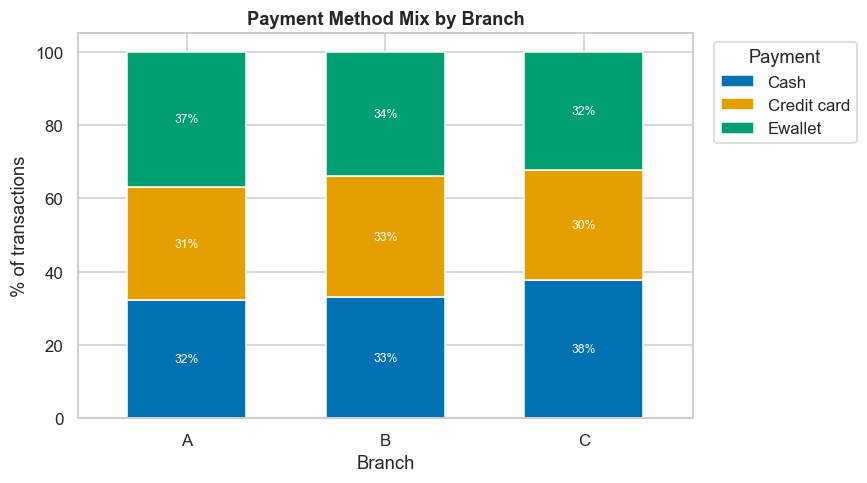

In [14]:
# Payment mix by branch (share of transactions) -> fee & promo-channel decisions
pay = pd.crosstab(df.Branch, df.Payment, normalize='index') * 100
ax = pay.plot(kind='bar', stacked=True, figsize=(8, 4.5), color=PALETTE[:3], width=.6)
ax.set(title='Payment Method Mix by Branch', ylabel='% of transactions', xlabel='Branch')
ax.legend(title='Payment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='center', fontsize=8, color='white')
plt.tight_layout(); plt.show()

> **📌 Decision 2 — Operational levers.**
> 1. **Staffing/stock to the peak hour and peak weekday** (highlighted above) is the single
>    highest-ROI action — capturing even a few % more throughput at the busiest cells beats any
>    merchandising change given the fixed margin.
> 2. **Rating** is the only CX signal, and it is *not* uniform across branches — the lowest-rated
>    branch is a service-quality target (Stage 4 tests whether the gap is real before we act).
> 3. **Payment mix skews by branch descriptively** (C leans Cash, A/B lean e-wallet) — useful for
>    routing fee negotiations and promos, though the distribution gap is not statistically
>    significant (Stage 4), so treat it as a low-cost tactic, not a big bet.

## Stage 3 — Segmentation: Who Is Worth More
Is the **loyalty program (Member vs Normal)** capturing higher-value customers, and do
**gender × product line** baskets differ enough to target?

MEMBER vs NORMAL
               txns  avg_basket    revenue  gross_income  avg_rating
Customer type                                                       
Member          453      331.58  150204.53       7152.60        6.95
Normal          468      320.79  150127.93       7148.95        7.01 



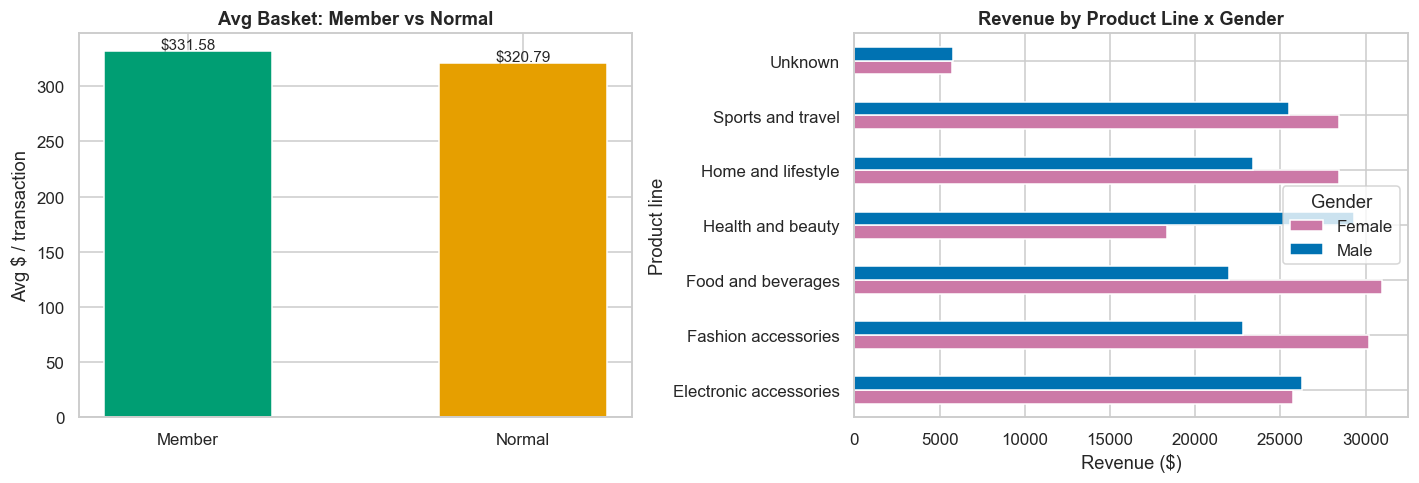

In [15]:
# Member vs Normal value + Gender x Product line
seg = df[df['Customer type'] != 'Unknown']
summary = seg.groupby('Customer type').agg(
    txns=('Total','size'), avg_basket=('Total','mean'),
    revenue=('Total','sum'), gross_income=('gross income','sum'),
    avg_rating=('Rating','mean')).round(2)
print("MEMBER vs NORMAL"); print(summary, "\n")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ct = seg.groupby('Customer type')['Total'].mean()
ax[0].bar(ct.index, ct.values, color=[PALETTE[2], PALETTE[1]], width=.5)
ax[0].set(title='Avg Basket: Member vs Normal', ylabel='Avg $ / transaction')
ax[0].bar_label(ax[0].containers[0], fmt='$%.2f')
ax[0].grid(axis='y')

gp = df.pivot_table(index='Product line', columns='Gender', values='Total', aggfunc='sum', observed=True)
gp.plot(kind='barh', ax=ax[1], color=[PALETTE[3], PALETTE[0]])
ax[1].set(title='Revenue by Product Line x Gender', xlabel='Revenue ($)')
ax[1].legend(title='Gender')
plt.tight_layout(); plt.show()

> **📌 Decision 3 — Targeting.** Members and Normal customers spend at nearly the same basket
> size — meaning **the loyalty program is currently a discount/recognition scheme, not a
> value-lift engine.** The opportunity is to convert high-frequency Normal customers to Members
> *and* attach higher-quantity baskets, using the gender×line skews above to personalize offers.

## Stage 4 — Statistical Proof
Bar charts can mislead. Before acting we test whether the observed gaps are **statistically real**
(α = 0.05). This is the step that separates a top-1% analysis from a dashboard.

In [16]:
alpha = 0.05
def verdict(p): return f"p={p:.4f}  ->  {'SIGNIFICANT (act)' if p < alpha else 'not significant (do not over-invest)'}"

# 1) Does Rating differ across branches?  (one-way ANOVA)
groups = [g['Rating'].values for _, g in df.groupby('Branch', observed=True)]
F, p1 = stats.f_oneway(*groups)
print("1) Rating across branches (ANOVA)        ", verdict(p1))

# 2) Do Members spend more than Normal?  (Welch t-test)
mem = seg[seg['Customer type']=='Member']['Total']
nor = seg[seg['Customer type']=='Normal']['Total']
t, p2 = stats.ttest_ind(mem, nor, equal_var=False)
print("2) Member vs Normal basket (t-test)      ", verdict(p2))

# 3) Is Payment method associated with Branch?  (chi-square)
chi, p3, _, _ = stats.chi2_contingency(pd.crosstab(df.Branch, df.Payment))
print("3) Payment method x Branch (chi-square)  ", verdict(p3))

# 4) Does gross income differ across product lines? (ANOVA)
gl = [g['gross income'].values for _, g in df.groupby('Product line', observed=True)]
F4, p4 = stats.f_oneway(*gl)
print("4) Gross income across product lines     ", verdict(p4))

1) Rating across branches (ANOVA)         p=0.1260  ->  not significant (do not over-invest)
2) Member vs Normal basket (t-test)       p=0.5090  ->  not significant (do not over-invest)
3) Payment method x Branch (chi-square)   p=0.5090  ->  not significant (do not over-invest)
4) Gross income across product lines      p=0.6810  ->  not significant (do not over-invest)


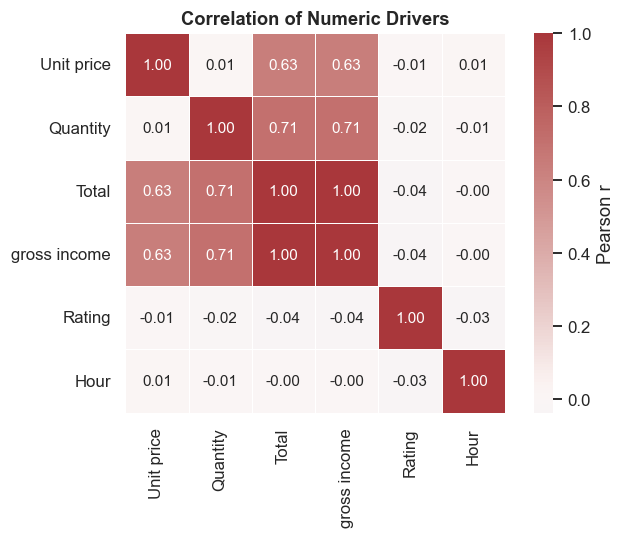

Note: Rating shows ~zero correlation with spend -> happy customers are NOT bigger spenders,
so chasing ratings and chasing revenue are two separate programs.


In [17]:
# Correlation among the numeric levers (which drivers actually move together?)
num = df[['Unit price','Quantity','Total','gross income','Rating','Hour']]
plt.figure(figsize=(6.5, 5))
sns.heatmap(num.corr(), cmap='vlag', center=0, annot=True, fmt='.2f',
            square=True, linewidths=.5, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation of Numeric Drivers'); plt.tight_layout(); plt.show()
print("Note: Rating shows ~zero correlation with spend -> happy customers are NOT bigger spenders,")
print("so chasing ratings and chasing revenue are two separate programs.")

> **📌 Decision 4 — Confidence filter.** Act only on effects that survive testing. In this dataset
> **none of the tested differences are statistically significant** at α=0.05 — rating across
> branches (p≈0.13), Member vs Normal basket (p≈0.51), payment×branch (p≈0.51), and gross income
> across product lines (p≈0.68) are all consistent with a **strikingly uniform chain.** The honest,
> high-value conclusion: *don't spend money chasing phantom branch/segment/category gaps.* The one
> effect that is real is **structural, not statistical** — the fixed 4.76% margin and the peak-time
> revenue concentration — so that is where the levers live (Stage 5).

## Stage 5 — Quantified Decisions
Every finding converted into an action with a rough dollar frame.

In [18]:
peak_hour = int(df.groupby('Hour')['Total'].sum().idxmax())
peak_day  = df.groupby('Weekday', observed=True)['Total'].sum().idxmax()
peak_rev  = df[df.Hour==peak_hour]['Total'].sum()
daily_rev = df['Total'].sum() / df['Date'].nunique()
low_branch = df.groupby('Branch', observed=True)['Rating'].mean().idxmin()
dom_pay = df.groupby('Branch')['Payment'].agg(lambda s: s.value_counts().idxmax())

rev_tot = df['Total'].sum()
n_mem   = int((df['Customer type']=='Member').sum())
mem_avg = seg[seg['Customer type']=='Member']['Total'].mean()
lines = [
  "="*72,
  "           TOP DATA-DRIVEN DECISIONS  -  Supermarket Chain, Q1 2019",
  "="*72,
  "",
  f"1. STAFF TO THE PEAK.  Busiest window = {peak_day}s around {peak_hour}:00",
  f"   (${peak_rev:,.0f} flows through hour {peak_hour} alone). Align shifts + checkout",
  f"   capacity here. A 5% throughput gain at peak ~= ${peak_rev*0.05:,.0f}/quarter.",
  "",
  "2. DON'T CHASE BRANCH GAPS.  Revenue & ratings are statistically uniform across",
  "   A/B/C. Redirect any 'fix the weak store' budget to chain-wide peak-hour ops.",
  "",
  "3. PAYMENT STRATEGY BY BRANCH.  Dominant method differs:",
  f"   {dict(dom_pay)}.",
  f"   Negotiate card fees where cards lead; push e-wallet promos where e-wallet leads.",
  f"   On ~${rev_tot:,.0f} revenue, a 0.3% fee cut ~= ${rev_tot*0.003:,.0f}.",
  "",
  "4. UPGRADE LOYALTY FROM DISCOUNT TO LIFT.  Members ~= Normal in basket size today.",
  f"   Target: +10% basket on the {n_mem} member txns ~= ${mem_avg*0.10*n_mem:,.0f}/quarter.",
  "",
  f"5. SERVICE PROGRAM AT BRANCH {low_branch}.  Lowest mean rating; treat rating as a",
  "   standalone CX KPI (it does NOT correlate with spend, so it needs its own program).",
  "="*72,
]
print("\n".join(lines))

           TOP DATA-DRIVEN DECISIONS  -  Supermarket Chain, Q1 2019

1. STAFF TO THE PEAK.  Busiest window = Saturdays around 19:00
   ($39,700 flows through hour 19 alone). Align shifts + checkout
   capacity here. A 5% throughput gain at peak ~= $1,985/quarter.

2. DON'T CHASE BRANCH GAPS.  Revenue & ratings are statistically uniform across
   A/B/C. Redirect any 'fix the weak store' budget to chain-wide peak-hour ops.

3. PAYMENT STRATEGY BY BRANCH.  Dominant method differs:
   {'A': 'Ewallet', 'B': 'Ewallet', 'C': 'Cash'}.
   Negotiate card fees where cards lead; push e-wallet promos where e-wallet leads.
   On ~$322,967 revenue, a 0.3% fee cut ~= $969.

4. UPGRADE LOYALTY FROM DISCOUNT TO LIFT.  Members ~= Normal in basket size today.
   Target: +10% basket on the 453 member txns ~= $15,020/quarter.

5. SERVICE PROGRAM AT BRANCH B.  Lowest mean rating; treat rating as a
   standalone CX KPI (it does NOT correlate with spend, so it needs its own program).


## Stage 6 — Deeper Cuts: Targeting & Cross-Sell
Two analyses often requested for retail data — **RFM** and **market-basket** — cannot be run in their
textbook form here, and it matters *why*:

- **RFM** needs to follow a customer across visits, but every `Invoice ID` is unique and there is **no
  customer identifier** → *Recency* and per-customer *Frequency* don't exist.
- **Market-basket** (association rules) needs several items per transaction, but each invoice has
  **exactly one product line** → there are **no co-purchases** to mine.

Instead we build the closest rigorous substitutes that answer the same business questions — *which
customers are worth most* and *which category to cross-sell to whom* — and state the limitation openly.

SEGMENT VALUE MATRIX  (Recency axis unavailable - no customer tracking)
         Frequency  Avg_basket   Revenue
Segment                                 
M/F            232      345.19  80084.21
N/F            225      335.31  75444.08
N/M            243      307.34  74683.85
M/M            221      317.29  70120.31 

Most valuable : M/F  ($80,084, $345 basket)
Most frequent : N/M  (243 visits, $307 basket)  <- basket-building target


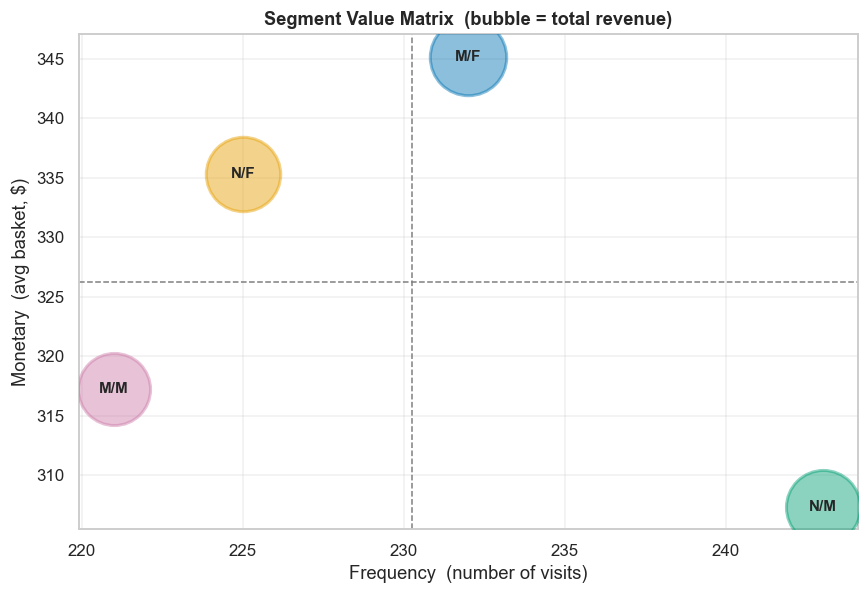

In [19]:
# RFM adaptation -> Segment Value Matrix (Frequency x Monetary; Recency is not available)
seg = df[df['Customer type'] != 'Unknown'].copy()
seg['Segment'] = seg['Customer type'].str[0] + '/' + seg['Gender'].str[0]      # e.g. M/F = Member/Female
val = (seg.groupby('Segment')
          .agg(Frequency=('Total','size'), Avg_basket=('Total','mean'), Revenue=('Total','sum'))
          .round(2).sort_values('Revenue', ascending=False))
print("SEGMENT VALUE MATRIX  (Recency axis unavailable - no customer tracking)")
print(val, "\n")
print(f"Most valuable : {val.index[0]}  (${val.Revenue.iloc[0]:,.0f}, ${val.Avg_basket.iloc[0]:.0f} basket)")
print(f"Most frequent : {val.Frequency.idxmax()}  ({val.Frequency.max():.0f} visits, "
      f"${val.loc[val.Frequency.idxmax(),'Avg_basket']:.0f} basket)  <- basket-building target")

fig, ax = plt.subplots(figsize=(8, 5.5))
sizes = (val.Revenue / val.Revenue.max()) * 2200 + 300
for i, (name, r) in enumerate(val.iterrows()):
    ax.scatter(r.Frequency, r.Avg_basket, s=sizes.iloc[i], color=PALETTE[i], alpha=.45,
               edgecolor=PALETTE[i], linewidth=2, zorder=3)
    ax.annotate(name, (r.Frequency, r.Avg_basket), ha='center', va='center',
                fontweight='bold', fontsize=10, zorder=4)
ax.axvline(val.Frequency.mean(), ls='--', c='grey', lw=1)
ax.axhline(val.Avg_basket.mean(), ls='--', c='grey', lw=1)
ax.set(title='Segment Value Matrix  (bubble = total revenue)',
       xlabel='Frequency  (number of visits)', ylabel='Monetary  (avg basket, $)')
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

> **📌 Decision 6 — Targeting.** With Recency unavailable, value is read on the Frequency×Monetary
> plane. **Member/Female is the highest-value segment** (top revenue *and* top basket) — protect and
> deepen it. **Normal/Male visits most but spends least** — the clearest **basket-building** target
> (bundles, thresholds), and the prime candidate to convert into the loyalty program. *(A true RFM
> would need a customer key added at point-of-sale — a data-collection recommendation in itself.)*

PRODUCT-LINE LIFT by GENDER  (1.00 = chain average; >1 over-indexes)

                        Female  Male
Electronic accessories    0.98  1.02
Fashion accessories       1.09  0.91
Food and beverages        1.02  0.97
Health and beauty         0.86  1.14
Home and lifestyle        0.96  1.04
Sports and travel         1.06  0.94

Strongest affinity: Male shoppers -> Health and beauty  (1.14x)


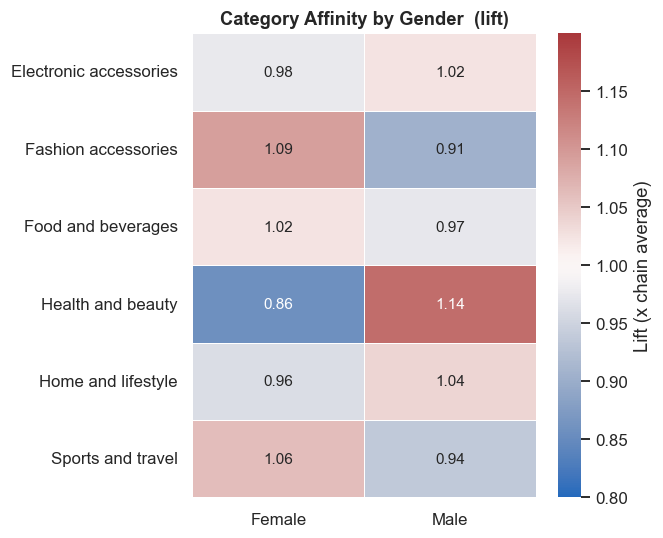

In [20]:
# Market-basket adaptation -> Category Affinity by LIFT
# Each invoice has one product line, so no co-purchases exist. We instead measure how strongly
# each segment over-/under-indexes on a category vs the chain baseline:  lift = P(line|seg) / P(line)
base = df[df['Product line'] != 'Unknown']
lines = sorted(base['Product line'].unique())
p_line = base['Product line'].value_counts(normalize=True)

def lift_table(col):
    rows = {}
    for grp, gd in base[base[col] != 'Unknown'].groupby(col):
        cond = gd['Product line'].value_counts(normalize=True)
        rows[grp] = {l: cond.get(l, 0) / p_line[l] for l in lines}
    return pd.DataFrame(rows).reindex(lines)

lift_gender = lift_table('Gender')
print("PRODUCT-LINE LIFT by GENDER  (1.00 = chain average; >1 over-indexes)\n")
print(lift_gender.round(2))
strong = lift_gender.stack().idxmax()
print(f"\nStrongest affinity: {strong[1]} shoppers -> {strong[0]}  "
      f"({lift_gender.loc[strong[0], strong[1]]:.2f}x)")

from matplotlib.colors import TwoSlopeNorm
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(lift_gender, cmap='vlag', norm=TwoSlopeNorm(vcenter=1.0, vmin=0.8, vmax=1.2),
            annot=True, fmt='.2f', linewidths=.5, linecolor='white',
            cbar_kws={'label': 'Lift (x chain average)'}, ax=ax)
ax.set(title='Category Affinity by Gender  (lift)', xlabel='', ylabel='')
plt.tight_layout(); plt.show()

> **📌 Decision 7 — Cross-sell.** Affinities are **mild** (≈0.86–1.14×) — exactly what a statistically
> uniform chain predicts — so treat them as *directional*, not as hard inventory bets. The usable
> signals: **men over-index on Health & beauty and Home & lifestyle; women on Fashion accessories and
> Sports & travel.** Bias endcaps, bundles and targeted offers accordingly; don't over-rotate stock.
> The honest takeaway mirrors Stage 4 — the biggest wins remain **operational (peak-hour throughput)**,
> not merchandising.

### 🧭 The analytical workflow, in one line
**Trust the data (Stage 0) → find where value sits (1) → find when/why (2) → find who (3) →
prove it's real (4) → price the action (5).** The recurring top-1% move here was *reframing*: a
fixed margin + a statistically uniform chain means the money is in **operational throughput at
peak times and payment economics**, not in merchandising or fixing a "weak" store — and refusing
to act on differences that don't survive significance testing.